In [1]:
import os
import time
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from utils.DenseCL import DenseCL
import matplotlib.pyplot as plt

2026-04-23 12:05:20.759231: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 12:05:21.428427: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-23 12:05:23.854904: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# # 1. Build backbone the same way you did during pretraining
# backbone = backbone = tf.keras.applications.ResNet50(
#         include_top=False, weights="imagenet", input_shape=(224, 224, 3)
#     )

# # 2. Wrap in DenseCL with the same hyperparameters
# model = DenseCL(backbone, momentum=0.9995, temperature=0.2,
#                 lambda_weight=0.5, queue_size=4096,
#                 warmup_epochs=10, ramp_epochs=10)

# # 3. Build it
# dummy = tf.zeros((1, 224, 224, 3))
# _ = model(dummy, training=False)

# # 4. Load with skip_mismatch — the backbone weights WILL match
# #    because backbone layers have stable names from your factory;
# #    only the heads are the unstable ones
# model.load_weights("trained_backbones/backbone_test1/DenseCL.keras",
#                    skip_mismatch=True)

# # 5. Save ONLY the backbone as a clean standalone model
# model.backbone.save("trained_backbones/backbone_test1/DenseCL.keras")

In [3]:
mixed_precision.set_global_policy("mixed_float16")

In [4]:
feature_set = "pbi"
# feature_set = "streamer"

In [5]:
# # Contrastive learning pretrained weights
base_model_path = "backbones/dense_1791231432/cp-0200.keras"
backbone = tf.keras.models.load_model(base_model_path)
mode = f"contrastive"

I0000 00:00:1776967527.865233  240849 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2250 MB memory:  -> device: 0, name: NVIDIA T550 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 7.5
2026-04-23 12:05:30.254445: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
/home/marcus/DLA/geospacial_dla_25-26/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 221 variables whereas the saved optimizer has 233 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: A total of 4 objects could not be loaded. Example error message for object <Conv2D name=conv2d_1, built=True>:

Layer 'conv2d_1' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<Conv2D name=conv2d_1, built=True>, <Dense name=dense_1, built=True>, <Dense name=dense_3, built=True>, <Conv2D name=conv2d_3, built=True>]

In [ ]:
# Imagenet pretrained weights
# backbone = tf.keras.applications.ResNet50(
#     include_top=False,
#     weights="imagenet",
#     input_shape=(224, 224, 3)
# )
# mode = "imagenet"

In [ ]:
# Randomly initialized weights
# backbone = tf.keras.applications.ResNet50(
#     include_top=False,
#     weights=None,
#     input_shape=(224, 224, 3)
# )
# mode = "random"

In [ ]:
run_name = f"classification_head_{int(time.time())}_{mode}"

In [ ]:
backbone.trainable = False

In [ ]:
data_dir = f"data/data_sample_2_{feature_set}"
class_names = sorted(os.listdir(data_dir))

In [ ]:
paths = []
labels = []
for label, class_name in enumerate(class_names):
    class_dir = os.path.join(data_dir, class_name)
    for fname in os.listdir(class_dir):
        paths.append(os.path.join(class_dir, fname))
        labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

In [ ]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42,
)

# Compute class_weight from the actual train split (not the full dataset)
# so it stays correct when you move this to k-fold CV.
train_neg = int((train_labels == 0).sum())
train_pos = int((train_labels == 1).sum())
train_total = train_neg + train_pos
class_weight = {
    0: train_total / (2 * train_neg),
    1: train_total / (2 * train_pos),
}
print(f"train pos/neg: {train_pos}/{train_neg}  class_weight: {class_weight}")

# >>> TODO: replace this single split with the same stratified 5-fold CV
# you use for the linear-probe / kNN evaluation. With ~50 val images a
# single split is too noisy to compare checkpoints (one image ≈ 0.02 acc).

train pos/neg: 80/320  class_weight: {0: 0.625, 1: 2.5}


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 200

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)  # ResNet caffe-mode preprocessing — apply ONCE
    return img, label


train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels.astype("float32")))
    .shuffle(len(train_paths), seed=42)
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels.astype("float32")))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
model = tf.keras.Sequential([
    backbone,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",  # keep final layer in fp32 under mixed precision
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    ),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc_roc", curve="ROC"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

In [ ]:
log_dir = f"logs/{run_name}"
os.makedirs(log_dir, exist_ok=True)
callbacks = [
    # Monitor val_auc_pr, not val_accuracy. With 80/20 imbalance and only
    # ~50 val images, accuracy is both the wrong objective and the noisiest
    # signal. AUC-PR is what you actually care about downstream.
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc_pr",
        mode="max",
        min_delta=0.01,
        patience=20,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.TensorBoard(log_dir=log_dir),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc_pr",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
    ),
    tf.keras.callbacks.CSVLogger(f"{log_dir}/training.csv"),
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)
results = model.evaluate(val_ds)
model.save(f"{log_dir}/model.keras")

Epoch 1/200


2026-04-08 20:42:52.699131: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 45433344 bytes after encountering the first element of size 45433344 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.5700 - auc_pr: 0.2285 - auc_roc: 0.5671 - loss: 0.6923 - precision: 0.2527 - recall: 0.5875 - val_accuracy: 0.6100 - val_auc_pr: 0.2863 - val_auc_roc: 0.6666 - val_loss: 0.6797 - val_precision: 0.3061 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 2/200


2026-04-08 20:43:29.975010: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 45433344 bytes after encountering the first element of size 45433344 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7050 - auc_pr: 0.3155 - auc_roc: 0.6839 - loss: 0.6481 - precision: 0.3273 - recall: 0.4500 - val_accuracy: 0.5200 - val_auc_pr: 0.3686 - val_auc_roc: 0.7181 - val_loss: 0.6948 - val_precision: 0.2667 - val_recall: 0.8000 - learning_rate: 0.0010
Epoch 3/200


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7525 - auc_pr: 0.5629 - auc_roc: 0.8455 - loss: 0.5003 - precision: 0.4317 - recall: 0.7500 - val_accuracy: 0.7200 - val_auc_pr: 0.4025 - val_auc_roc: 0.7903 - val_loss: 0.5836 - val_precision: 0.3947 - val_recall: 0.7500 - learning_rate: 1.5625e-05
Epoch 49/200


2026-04-08 20:50:18.500033: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 45433344 bytes after encountering the first element of size 45433344 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7550 - auc_pr: 0.5638 - auc_roc: 0.8458 - loss: 0.5003 - precision: 0.4348 - recall: 0.7500 - val_accuracy: 0.7400 - val_auc_pr: 0.4006 - val_auc_roc: 0.7888 - val_loss: 0.5818 - val_precision: 0.4167 - val_recall: 0.7500 - learning_rate: 1.5625e-05
Epoch 50/200


2026-04-08 20:50:27.159718: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 45433344 bytes after encountering the first element of size 45433344 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7575 - auc_pr: 0.5636 - auc_roc: 0.8459 - loss: 0.5000 - precision: 0.4380 - recall: 0.7500 - val_accuracy: 0.7200 - val_auc_pr: 0.4006 - val_auc_roc: 0.7884 - val_loss: 0.5831 - val_precision: 0.3947 - val_recall: 0.7500 - learning_rate: 7.8125e-06
Epoch 51/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7525 - auc_pr: 0.5645 - auc_roc: 0.8462 - loss: 0.4999 - precision: 0.4317 - recall: 0.7500 - val_accuracy: 0.7300 - val_auc_pr: 0.4011 - val_auc_roc: 0.7894 - val_loss: 0.5858 - val_precision: 0.4103 - val_recall: 0.8000 - learning_rate: 7.8125e-06
Epoch 52/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7525 - auc_pr: 0.5627 - auc_roc: 0.8457 - loss: 0.5002 - precision: 0.4317 - recall: 0.7500 - val_accuracy: 0.7200 - val_auc_pr: 0.4042 - val_auc_roc: 0.7900 - val_loss: 0.5889 - val_precision: 0.4000 - val_recall: 0.8000 - learning_rate: 7.8125e-06
Epoch 53/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7550 - auc

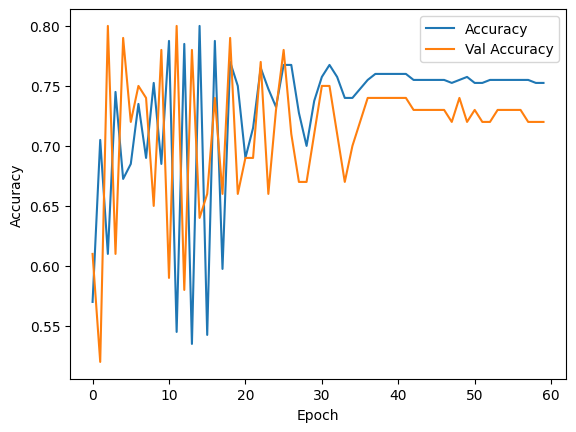

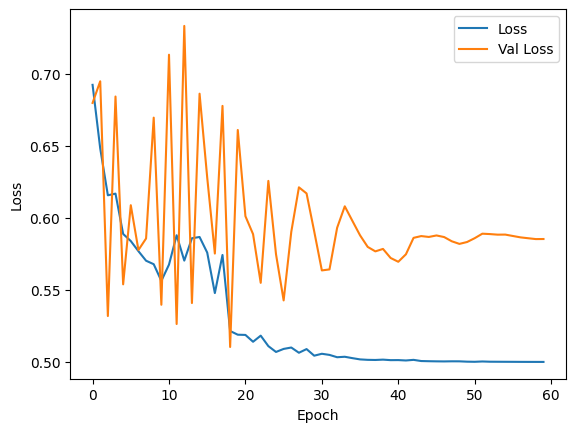

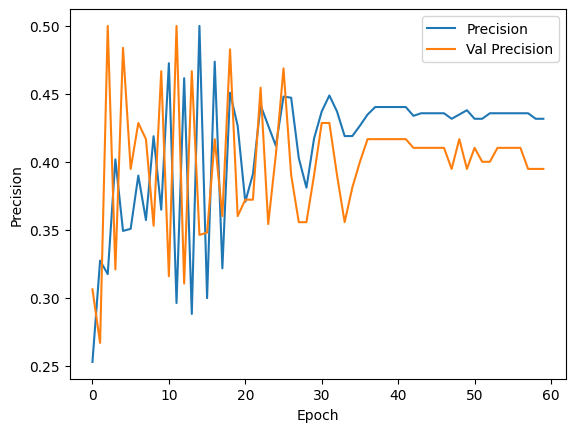

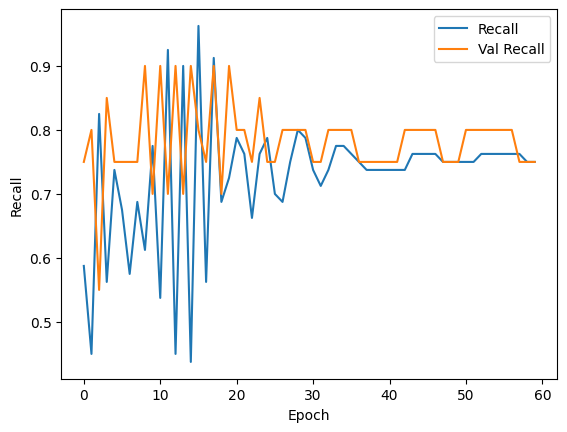

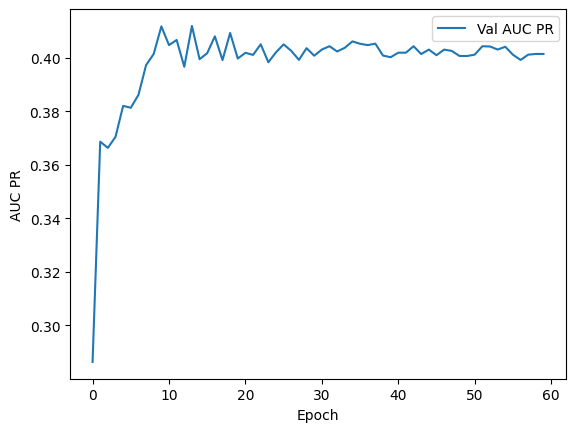

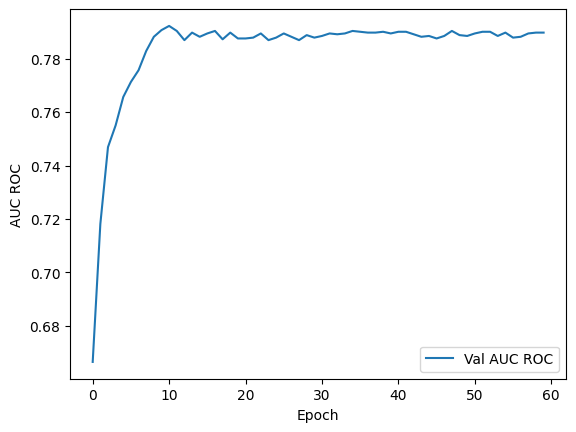

In [ ]:
df_hist = pd.read_csv(f"{log_dir}/training.csv")

plt.plot(df_hist["epoch"], df_hist["accuracy"], label="Accuracy")
plt.plot(df_hist["epoch"], df_hist["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(f"{log_dir}/accuracy_plot.png")
plt.show()

plt.plot(df_hist["epoch"], df_hist["loss"], label="Loss")
plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f"{log_dir}/loss_plot.png")
plt.show()

plt.plot(df_hist["epoch"], df_hist["precision"], label="Precision")
plt.plot(df_hist["epoch"], df_hist["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.legend()
plt.savefig(f"{log_dir}/precision_plot.png")
plt.show()

plt.plot(df_hist["epoch"], df_hist["recall"], label="Recall")
plt.plot(df_hist["epoch"], df_hist["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()
plt.savefig(f"{log_dir}/recall_plot.png")
plt.show()

plt.plot(df_hist["epoch"], df_hist["val_auc_pr"], label="Val AUC PR")
plt.xlabel("Epoch")
plt.ylabel("AUC PR")
plt.legend()
plt.savefig(f"{log_dir}/auc_pr_plot.png")
plt.show()

plt.plot(df_hist["epoch"], df_hist["val_auc_roc"], label="Val AUC ROC")
plt.xlabel("Epoch")
plt.ylabel("AUC ROC")
plt.legend()
plt.savefig(f"{log_dir}/auc_roc_plot.png")
plt.show()
